# Men's Rankings

Get ratings of each team in a given year. This file needs to be ran for every relevant year (2012 to 2024). 

### Data Setup

In [1]:
import pandas as pd

season = 2012

df = pd.read_parquet(fr'..\data\unprocessed\sports_reference\sports_reference_{season}.parquet')

df

,Date,Team,Location,Opponent,Result,Team Score,Opponent Score,Team FG,Team FGA,Team FG%,...,Opponent TOV,Opponent PF,Overtimes Amount,Overtime,Score Differential,Adjusted Score Differential,Possessions,Team PPP,Opponent PPP,Tempo
0,2011-11-11,Air Force,1,Army,1,87.0,71.0,29.0,52.0,0.558,...,24.0,29.0,0,0,16.0,1.475419,85.64,1.015880,0.829052,85.640000
1,2011-11-12,Air Force,0,Virginia Military Institute,1,75.0,65.0,28.0,56.0,0.500,...,14.0,21.0,0,0,10.0,1.381279,68.76,1.090750,0.945317,68.760000
2,2011-11-23,Air Force,1,Colorado,-1,73.0,76.0,25.0,62.0,0.403,...,17.0,22.0,1,1,-3.0,1.166625,70.08,1.041667,1.084475,62.293333
3,2011-12-03,Air Force,-1,Drake,-1,60.0,62.0,16.0,41.0,0.390,...,13.0,26.0,0,0,-2.0,1.102120,67.02,0.895255,0.925097,67.020000
4,2011-12-07,Air Force,1,Wright State,1,55.0,34.0,19.0,45.0,0.422,...,16.0,14.0,0,0,21.0,1.500000,60.10,0.915141,0.565724,60.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10555,2012-02-18,Youngstown State,-1,Austin Peay,-1,68.0,71.0,24.0,56.0,0.429,...,13.0,16.0,0,0,-3.0,1.166625,66.14,1.028122,1.073480,66.140000
10556,2012-02-23,Youngstown State,1,Wright State,1,61.0,54.0,22.0,49.0,0.449,...,15.0,16.0,0,0,7.0,1.313867,66.20,0.921450,0.815710,66.200000
10557,2012-02-25,Youngstown State,1,Detroit Mercy,-1,74.0,76.0,23.0,50.0,0.460,...,11.0,24.0,0,0,-2.0,1.102120,64.92,1.139864,1.170672,64.920000
10558,2012-02-28,Youngstown State,1,Green Bay,1,77.0,60.0,29.0,61.0,0.475,...,17.0,15.0,0,0,17.0,1.488021,64.56,1.192689,0.929368,64.560000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10560 entries, 0 to 10559
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         10560 non-null  datetime64[ns]
 1   Team                         10560 non-null  object        
 2   Location                     10560 non-null  int8          
 3   Opponent                     10560 non-null  object        
 4   Result                       10560 non-null  int8          
 5   Team Score                   10560 non-null  float64       
 6   Opponent Score               10560 non-null  float64       
 7   Team FG                      10560 non-null  float64       
 8   Team FGA                     10560 non-null  float64       
 9   Team FG%                     10560 non-null  float64       
 10  Team 3P                      10560 non-null  float64       
 11  Team 3PA                     10560 non-nu

### Model Building

##### Team Ratings

In [3]:
X = (
    pd.get_dummies(df['Team']).astype('int8') -
    pd.get_dummies(df['Opponent']).astype('int8')
)

X['Home Field Advantage'] = df['Location'].copy()

X

,Air Force,Akron,Alabama,Alabama A&M,Alabama State,Albany (NY),Alcorn State,American,Appalachian State,Arizona,...,William & Mary,Winthrop,Wisconsin,Wofford,Wright State,Wyoming,Xavier,Yale,Youngstown State,Home Field Advantage
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,-1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10555,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,-1
10556,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,-1,0,0,0,1,1
10557,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
10558,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1


In [4]:
from sklearn.model_selection import GroupKFold
import numpy as np

def get_gkf_data(X, y, w, groups, cv=3):
    """
    Converts training data to list of folds
    """
    np.random.seed(22)
    gkf = GroupKFold(n_splits=cv)

    data = []
    for train_index, test_index in gkf.split(X, y, groups=groups):
        X_train = X[train_index]
        X_test = X[test_index]

        y_train = y[train_index]
        y_test = y[test_index]

        # sample weights
        w_train = w[train_index]

        data.append((X_train, X_test, y_train, y_test, w_train))

    return data

cv_data = get_gkf_data(X.to_numpy(), df['Result'].to_numpy(), df['Adjusted Score Differential'].to_numpy(), df['Date'].to_numpy())

len(cv_data)

3

In [5]:
def rescale_weights(arr, minimum, maximum):
    """
    Rescale the weights array to match desired weights.
    Assumes the data is already transformed where a 1 point win is 1.00, a blowout is 1.50, and a tie is 0.50.
    Ties will be weighted as half the minimum.
    """

    arr_scaled = ((arr - 1.00) / 0.50) * (maximum - minimum) + minimum
    arr_scaled[arr == 0.50] = minimum / 2
    return arr_scaled

In [6]:
from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
import warnings
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, cv_data=cv_data):
    # model tuning
    C = trial.suggest_float('C', 0.1, 10, log=True)
    mod = LogisticRegression(penalty='l2', C=C, fit_intercept=False)
    minimum = trial.suggest_float('minimum', 0.1, 1.0, step=0.1)
    maximum = trial.suggest_float('maximum', 1.0, 8.0, step=0.5)

    # cross validation
    y_actuals = []
    y_preds = []
    for X_train, X_test, y_train, y_test, w_train in cv_data:
        y_actuals.append(y_test)

        weights = rescale_weights(w_train, minimum, maximum)

        with warnings.catch_warnings():
            warnings.filterwarnings('ignore')  # prevent convergence warnings
            mod.fit(X_train, y_train, sample_weight=weights)

        y_preds.append(mod.predict_proba(X_test)[:, 1])

    return log_loss(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22))
study.optimize(objective, n_trials=100, show_progress_bar=True)

study.best_params

  0%|          | 0/100 [00:00<?, ?it/s]

{'C': 0.6748502184888395, 'minimum': 0.5, 'maximum': 2.0}

In [7]:
minimum = study.best_params['minimum']
maximum = study.best_params['maximum']

weight = rescale_weights(df['Adjusted Score Differential'], minimum, maximum)

mod = LogisticRegression(penalty='l2', C=study.best_params['C'], fit_intercept=False)

mod.fit(X, df['Result'], sample_weight=weight)

df_ratings = pd.DataFrame(
    {
        'Team': X.columns,
        'BT Rating': mod.coef_[0]
    }
).sort_values(by=['BT Rating'], ascending=False, ignore_index=True)

df_ratings

,Team,BT Rating
0,Kentucky,3.565314
1,Syracuse,3.251568
2,North Carolina,3.127123
3,Murray State,3.016669
4,Michigan State,2.961660
...,...,...
340,FDU,-2.928444
341,Tennessee-Martin,-2.997665
342,Bryant,-3.115382
343,Towson,-3.159786


Make stronger adjustments based on strength of schedule

In [8]:
team_to_bt_rating = dict(zip(df_ratings['Team'], df_ratings['BT Rating']))

df['Opponent BT Rating'] = df['Opponent'].map(team_to_bt_rating)

df

,Date,Team,Location,Opponent,Result,Team Score,Opponent Score,Team FG,Team FGA,Team FG%,...,Opponent PF,Overtimes Amount,Overtime,Score Differential,Adjusted Score Differential,Possessions,Team PPP,Opponent PPP,Tempo,Opponent BT Rating
0,2011-11-11,Air Force,1,Army,1,87.0,71.0,29.0,52.0,0.558,...,29.0,0,0,16.0,1.475419,85.64,1.015880,0.829052,85.640000,-1.276910
1,2011-11-12,Air Force,0,Virginia Military Institute,1,75.0,65.0,28.0,56.0,0.500,...,21.0,0,0,10.0,1.381279,68.76,1.090750,0.945317,68.760000,-0.967284
2,2011-11-23,Air Force,1,Colorado,-1,73.0,76.0,25.0,62.0,0.403,...,22.0,1,1,-3.0,1.166625,70.08,1.041667,1.084475,62.293333,0.864416
3,2011-12-03,Air Force,-1,Drake,-1,60.0,62.0,16.0,41.0,0.390,...,26.0,0,0,-2.0,1.102120,67.02,0.895255,0.925097,67.020000,0.425106
4,2011-12-07,Air Force,1,Wright State,1,55.0,34.0,19.0,45.0,0.422,...,14.0,0,0,21.0,1.500000,60.10,0.915141,0.565724,60.100000,-0.436950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10555,2012-02-18,Youngstown State,-1,Austin Peay,-1,68.0,71.0,24.0,56.0,0.429,...,16.0,0,0,-3.0,1.166625,66.14,1.028122,1.073480,66.140000,-0.435965
10556,2012-02-23,Youngstown State,1,Wright State,1,61.0,54.0,22.0,49.0,0.449,...,16.0,0,0,7.0,1.313867,66.20,0.921450,0.815710,66.200000,-0.436950
10557,2012-02-25,Youngstown State,1,Detroit Mercy,-1,74.0,76.0,23.0,50.0,0.460,...,24.0,0,0,-2.0,1.102120,64.92,1.139864,1.170672,64.920000,0.637160
10558,2012-02-28,Youngstown State,1,Green Bay,1,77.0,60.0,29.0,61.0,0.475,...,15.0,0,0,17.0,1.488021,64.56,1.192689,0.929368,64.560000,0.110146


In [9]:
# make sure results are 1/-1 for win/loss for this chunk to work properly

def rescale_ratings(arr, minimum, maximum):
    """
    Rescale the ratings array to match desired weights.
    """
    return ((arr - arr.min()) / (arr.max() - arr.min())) * (maximum - minimum) + minimum

def get_sos(result: int, quantiles: list) -> pd.DataFrame:
    """
    Get the strength of teams beat/lost to at different quantiles.
    For example, best win or worst lost.
    """
    data = (
        df.loc[df['Result'] == result, :]
        .groupby(['Team'])['Opponent BT Rating']
        .quantile(quantiles)
        .reset_index()
        .pivot(index='Team', columns='level_1')
        .reset_index()
    )
    data.index.name = None
    if result > 0:
        data.columns = [v[0] if v[1] == '' else f'{v[1]} Win' for v in data.columns]
    else:
        data.columns = [v[0] if v[1] == '' else f'{v[1]} Loss' for v in data.columns]

    return data

df_advanced_ratings = pd.merge(
    get_sos(-1, [0.00, 0.10, 0.20]),
    get_sos(1, [1.00, 0.90, 0.80]),
    how='outer',
    on=['Team'],
)

df_advanced_ratings.insert(1, 'BT Rating', df_advanced_ratings['Team'].map(team_to_bt_rating))

# in case teams did not win or did not lose a game, just fill it with the team's own rating
for c in df_advanced_ratings.columns[1:]:
    df_advanced_ratings.loc[df_advanced_ratings[c].isna(), c] = df_advanced_ratings['BT Rating']

df_advanced_ratings.insert(
    1,
    'Rating',
    rescale_ratings(
        np.average(df_advanced_ratings.iloc[:, 1:], weights=[0.4] + [0.1]*6, axis=1),
        df_ratings['BT Rating'].min(),
        df_ratings['BT Rating'].max(),
    ),
)

df_advanced_ratings.sort_values(by=['Rating'], ascending=False, inplace=True, ignore_index=True)

df_advanced_ratings

,Team,Rating,BT Rating,0.0 Loss,0.1 Loss,0.2 Loss,0.8 Win,0.9 Win,1.0 Win
0,Kentucky,3.565314,3.565314,2.100623,2.127631,2.154640,1.950853,2.100623,3.127123
1,North Carolina,3.219256,3.127123,2.046872,2.078950,2.111029,1.645973,1.933744,2.961660
2,Syracuse,3.027328,3.251568,1.589953,1.617504,1.645056,1.593501,2.072651,2.355278
3,Ohio State,2.922136,2.748540,0.920081,1.660866,2.170416,2.113949,2.288196,2.961660
4,Duke,2.910209,2.624988,1.419239,1.712321,2.005404,1.846642,2.411251,3.127123
...,...,...,...,...,...,...,...,...,...
339,Alabama A&M,-3.145351,-2.465083,-2.919864,-2.321320,-1.528768,-1.621141,-1.574955,-1.528768
340,South Carolina State,-3.259338,-2.917500,-2.338022,-1.780929,-1.582971,-1.789145,-1.606186,-1.423227
341,Grambling,-3.271699,-2.919864,-2.321320,-1.806494,-1.574955,-1.737127,-1.632948,-1.528768
342,Maryland-Baltimore County,-3.396095,-2.809425,-3.531512,-1.604062,-1.214364,-2.421821,-1.868347,-1.314874


In [10]:
df_ratings_display = df_advanced_ratings[['Team', 'Rating']].copy()
df_ratings_display.index += 1

df_ratings_display['Strength'] = (np.exp(df_ratings_display['Rating'])/(1 + np.exp(df_ratings_display['Rating'])))*100

df_ratings_display

,Team,Rating,Strength
1,Kentucky,3.565314,97.249011
2,North Carolina,3.219256,96.155251
3,Syracuse,3.027328,95.379356
4,Ohio State,2.922136,94.892989
5,Duke,2.910209,94.834882
...,...,...,...
340,Alabama A&M,-3.145351,4.127486
341,South Carolina State,-3.259338,3.699279
342,Grambling,-3.271699,3.655496
343,Maryland-Baltimore County,-3.396095,3.241774


##### Adjusted Offense/Defense Ratings

In [11]:
X_offense = pd.get_dummies(
    df['Team']
).astype('int8')

X_offense.columns += ' Offense'

X_defense = -pd.get_dummies(
    df['Opponent']
).astype('int8')

X_defense.columns += ' Defense'

X = pd.concat([X_offense, X_defense], axis=1)

X['Home Field Advantage'] = df['Location'].copy()

X

,Air Force Offense,Akron Offense,Alabama Offense,Alabama A&M Offense,Alabama State Offense,Albany (NY) Offense,Alcorn State Offense,American Offense,Appalachian State Offense,Arizona Offense,...,William & Mary Defense,Winthrop Defense,Wisconsin Defense,Wofford Defense,Wright State Defense,Wyoming Defense,Xavier Defense,Yale Defense,Youngstown State Defense,Home Field Advantage
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,-1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10555,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
10556,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,-1,0,0,0,0,1
10557,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10558,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [12]:
def get_gkf_data(X, y, groups, cv=3):
    """
    Converts training data to list of folds
    """
    np.random.seed(22)
    gkf = GroupKFold(n_splits=cv)

    data = []
    for train_index, test_index in gkf.split(X, y, groups=groups):
        X_train = X[train_index, :]
        X_test = X[test_index, :]

        y_train = y[train_index]
        y_test = y[test_index]

        data.append([X_train, X_test, y_train, y_test])

    return data

cv_data = get_gkf_data(X.to_numpy(), df['Team PPP'].to_numpy(), df['Date'].to_numpy())

len(cv_data)

3

In [13]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, cv_data=cv_data):
    # model tuning
    alpha = trial.suggest_float('alpha', 0.1, 10, log=True)
    mod = Ridge(alpha=alpha)

    # cross validation
    y_actuals = []
    y_preds = []
    for X_train, X_test, y_train, y_test in cv_data:
        y_actuals.append(y_test)

        mod.fit(X_train, y_train)
        y_preds.append(mod.predict(X_test))

    return mean_squared_error(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22))
study.optimize(objective, n_trials=100, show_progress_bar=True)

study.best_params

  0%|          | 0/100 [00:00<?, ?it/s]

{'alpha': 2.536469134251355}

In [14]:
mod = Ridge(alpha=study.best_params['alpha'])

mod.fit(X, df['Team PPP'])

df_ppp = pd.DataFrame(
    {
        'Team': X.columns,
        'Rating': mod.coef_
    }
).sort_values(by=['Rating'], ascending=False, ignore_index=True)

df_ppp

,Team,Rating
0,Missouri Offense,0.206432
1,Florida Offense,0.166950
2,Kentucky Offense,0.165511
3,Creighton Offense,0.164292
4,Indiana Offense,0.163790
...,...,...
684,Prairie View Offense,-0.152894
685,Southeastern Louisiana Offense,-0.153465
686,Towson Offense,-0.156207
687,Longwood Defense,-0.179181


In [15]:
df_ppp.loc[df_ppp['Team'].str.contains('Home Field'), :]

,Team,Rating
216,Home Field Advantage,0.029504


In [16]:
df_ppp_offense = df_ppp.loc[df_ppp['Team'].str.contains(' Offense$', regex=True), :].reset_index(drop=True)

df_ppp_offense['Team'] = df_ppp_offense['Team'].str.replace(' Offense$', '', regex=True)

df_ppp_offense['Rating'] += mod.intercept_

df_ppp_offense.head(25)

,Team,Rating
0,Missouri,1.207558
1,Florida,1.168076
2,Kentucky,1.166637
3,Creighton,1.165419
4,Indiana,1.164917
5,Belmont,1.152413
6,Duke,1.147153
7,Kansas,1.136367
8,Ohio State,1.133910
9,Syracuse,1.132119


In [17]:
df_ppp_defense = df_ppp.loc[df_ppp['Team'].str.contains(' Defense$', regex=True), :].reset_index(drop=True)

df_ppp_defense['Team'] = df_ppp_defense['Team'].str.replace(' Defense$', '', regex=True)

df_ppp_defense['Rating'] = mod.intercept_ - df_ppp_defense['Rating']

df_ppp_defense.head(25)

,Team,Rating
0,Ohio State,0.843942
1,Wisconsin,0.853156
2,Michigan State,0.853857
3,Louisville,0.856289
4,Virginia,0.868151
5,Kentucky,0.868936
6,Kansas,0.876775
7,Florida State,0.877265
8,Alabama,0.879756
9,Georgetown,0.881764


In [18]:
df_ppp_all = pd.merge(
    df_ppp_offense.rename(columns={'Rating': 'Adjusted Offense'}),
    df_ppp_defense.rename(columns={'Rating': 'Adjusted Defense'}),
    how='inner',
    on=['Team']
)

df_ppp_all.head(25)

,Team,Adjusted Offense,Adjusted Defense
0,Missouri,1.207558,0.956841
1,Florida,1.168076,0.970174
2,Kentucky,1.166637,0.868936
3,Creighton,1.165419,1.005363
4,Indiana,1.164917,0.944676
5,Belmont,1.152413,0.962549
6,Duke,1.147153,0.950063
7,Kansas,1.136367,0.876775
8,Ohio State,1.133910,0.843942
9,Syracuse,1.132119,0.884929


##### Adjusted Pace Ratings

In [19]:
X = (
    pd.get_dummies(df['Team']).astype('int8') +
    pd.get_dummies(df['Opponent']).astype('int8')
)

X

,Air Force,Akron,Alabama,Alabama A&M,Alabama State,Albany (NY),Alcorn State,American,Appalachian State,Arizona,...,Wichita State,William & Mary,Winthrop,Wisconsin,Wofford,Wright State,Wyoming,Xavier,Yale,Youngstown State
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10555,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10556,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
10557,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10558,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [20]:
def get_gkf_data(X, y, groups, cv=3):
    """
    Converts training data to list of folds
    """
    np.random.seed(22)
    gkf = GroupKFold(n_splits=cv)

    data = []
    for train_index, test_index in gkf.split(X, y, groups=groups):
        X_train = X[train_index, :]
        X_test = X[test_index, :]

        y_train = y[train_index]
        y_test = y[test_index]

        data.append([X_train, X_test, y_train, y_test])

    return data

cv_data = get_gkf_data(X.to_numpy(), df['Tempo'].to_numpy(), df['Date'].to_numpy())

len(cv_data)

3

In [21]:
def objective(trial, cv_data=cv_data):
    # model tuning
    alpha = trial.suggest_float('alpha', 0.1, 10, log=True)
    mod = Ridge(alpha=alpha)

    # cross validation
    y_actuals = []
    y_preds = []
    for X_train, X_test, y_train, y_test in cv_data:
        y_actuals.append(y_test)

        mod.fit(X_train, y_train)
        y_preds.append(mod.predict(X_test))

    return mean_squared_error(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22))
study.optimize(objective, n_trials=100, show_progress_bar=True)

study.best_params

  0%|          | 0/100 [00:00<?, ?it/s]

{'alpha': 5.228342106272706}

In [22]:
mod = Ridge(alpha=study.best_params['alpha'])

mod.fit(X, df['Tempo'])

df_tempo = pd.DataFrame(
    {
        'Team': X.columns,
        'Adjusted Tempo': mod.coef_
    }
).sort_values(by=['Adjusted Tempo'], ascending=False, ignore_index=True)

df_tempo

,Team,Adjusted Tempo
0,Seattle,8.582570
1,Long Island University,7.750808
2,Massachusetts,7.554795
3,Virginia Military Institute,6.946515
4,North Carolina,6.583806
...,...,...
339,Southern Methodist,-5.705613
340,Stephen F. Austin,-5.758737
341,South Florida,-6.166518
342,Western Illinois,-6.868978


In [23]:
df_tempo['Adjusted Tempo'] += mod.intercept_

df_tempo

,Team,Adjusted Tempo
0,Seattle,75.341267
1,Long Island University,74.509504
2,Massachusetts,74.313492
3,Virginia Military Institute,73.705212
4,North Carolina,73.342503
...,...,...
339,Southern Methodist,61.053084
340,Stephen F. Austin,60.999960
341,South Florida,60.592179
342,Western Illinois,59.889719


### Visualizations

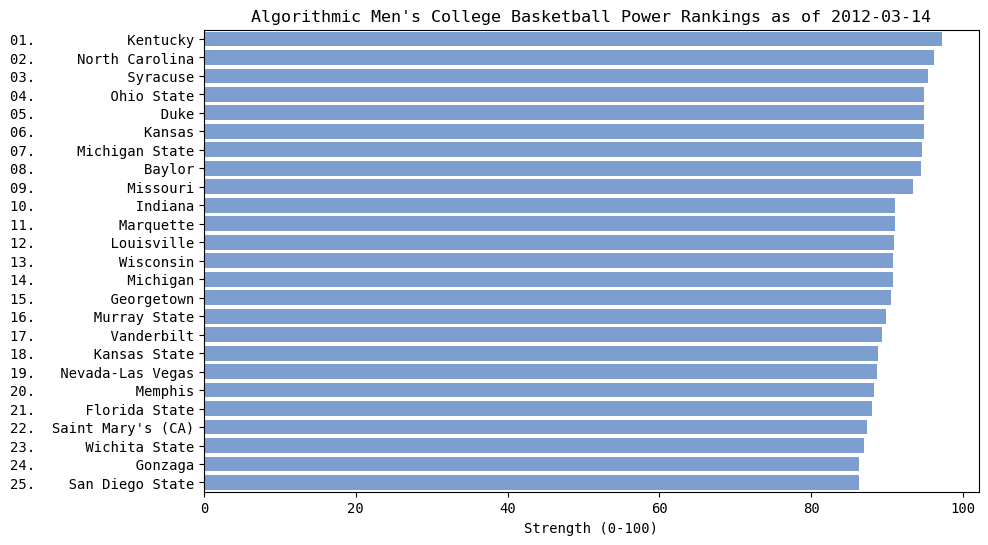

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'monospace'  # so spacing is consistent for y axis

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_ratings_display.head(25)['Strength'],
    y=(
        df_ratings_display.head(25).index.map(lambda x: str(x).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_ratings_display.head(25)['Team'].str.pad(max(df_ratings_display.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#6f9cde',
    dodge=False
)

plt.xlabel('Strength (0-100)')
plt.ylabel(None)
plt.title(f"Algorithmic Men's College Basketball Power Rankings as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

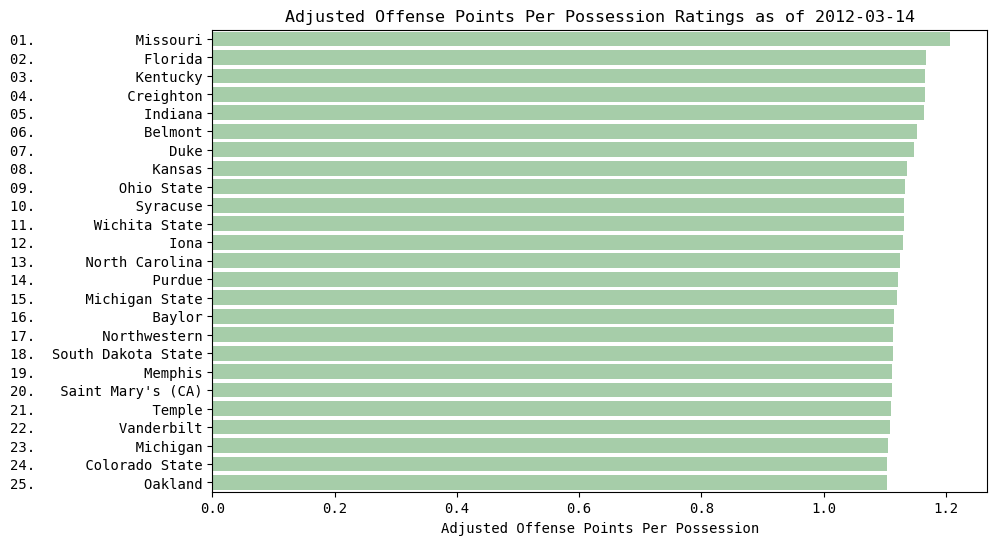

In [25]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_ppp_offense.head(25)['Rating'],
    y=(
        df_ppp_offense.head(25).index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_ppp_offense.head(25)['Team'].str.pad(max(df_ppp_offense.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#9fd4a3',
    dodge=False
)

plt.xlabel('Adjusted Offense Points Per Possession')
plt.ylabel(None)
plt.title(f"Adjusted Offense Points Per Possession Ratings as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

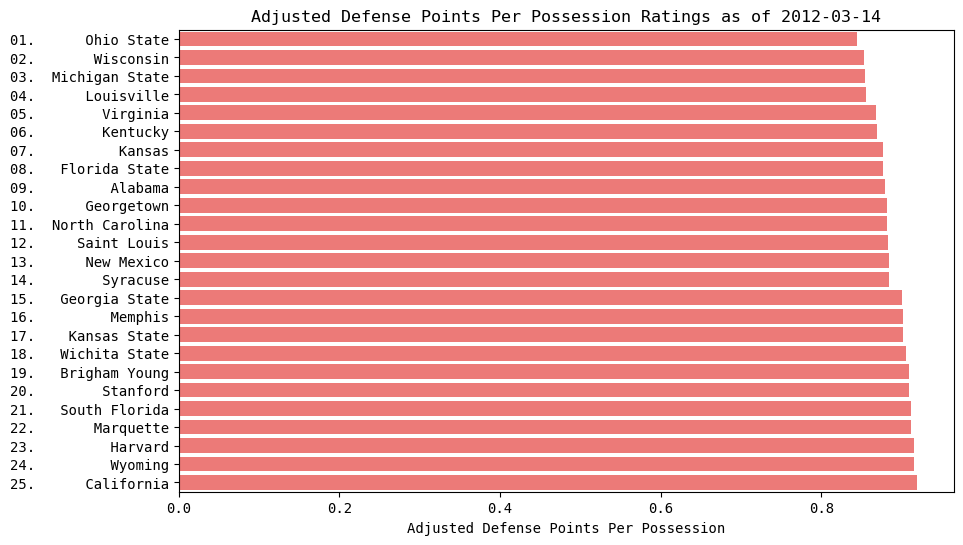

In [26]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_ppp_defense.head(25)['Rating'],
    y=(
        df_ppp_defense.head(25).index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_ppp_defense.head(25)['Team'].str.pad(max(df_ppp_defense.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#ff6865',
    dodge=False
)

plt.xlabel('Adjusted Defense Points Per Possession')
plt.ylabel(None)
plt.title(f"Adjusted Defense Points Per Possession Ratings as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

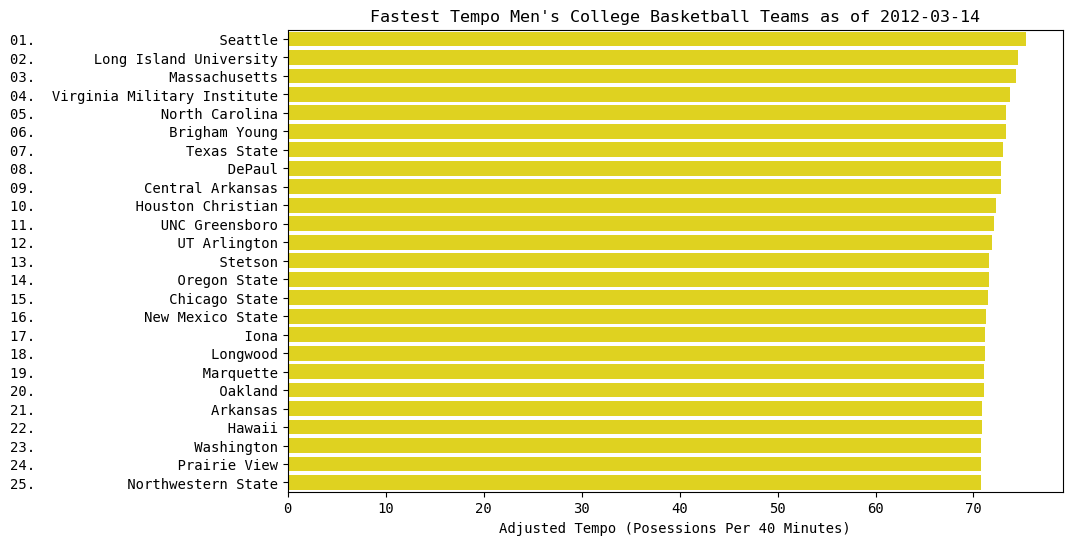

In [27]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_tempo.head(25)['Adjusted Tempo'],
    y=(
        df_tempo.head(25).index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_tempo.head(25)['Team'].str.pad(max(df_tempo.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#ffee00',
    dodge=False
)

plt.xlabel('Adjusted Tempo (Posessions Per 40 Minutes)')
plt.ylabel(None)
plt.title(f"Fastest Tempo Men's College Basketball Teams as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

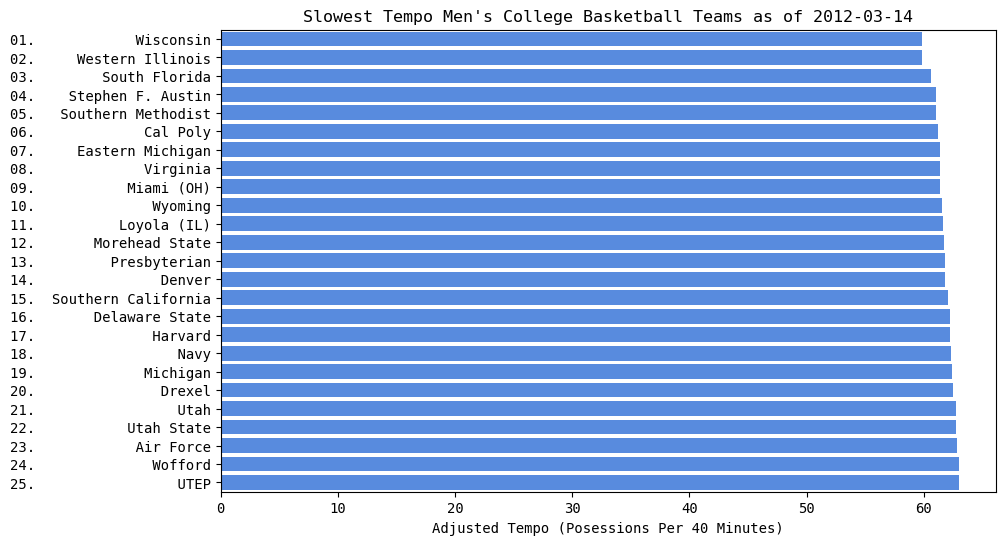

In [28]:
plt.figure(figsize=(10, 6))

df_slow = df_tempo.tail(25).iloc[::-1].reset_index(drop=True)

ax = sns.barplot(
    x=df_slow['Adjusted Tempo'],
    y=(
        df_slow.index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_slow['Team'].str.pad(max(df_slow['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#4285f4',
    dodge=False
)

plt.xlabel('Adjusted Tempo (Posessions Per 40 Minutes)')
plt.ylabel(None)
plt.title(f"Slowest Tempo Men's College Basketball Teams as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

In [29]:
import plotly.express as px

fig = px.scatter(
    df_ppp_all,
    x='Adjusted Offense',
    y='Adjusted Defense',
    hover_data='Team',
    title=f'Adjusted Points Per Possession Ratings as of {df["Date"].max().strftime("%Y-%m-%d")}',
    width=1_000, height=600,
)

fig.update_layout(
    font_family='monospace',
    hovermode='closest',
    yaxis=dict(
        showgrid=False,
        ticks='outside',
    ),
    xaxis=dict(
        showgrid=False,
        ticks='outside',
    ),
    xaxis_range=(df_ppp_all['Adjusted Offense'].min()-0.01, df_ppp_all['Adjusted Offense'].max()+0.01),
    yaxis_range=(df_ppp_all['Adjusted Defense'].max()+0.01, df_ppp_all['Adjusted Defense'].min()-0.01),
)

fig.update_traces(marker=dict(size=12))

fig.add_vline(
    x=df_ppp_all['Adjusted Offense'].mean(),
    line=dict(color="red", width=2, dash="dot")
)

fig.add_hline(
    y=df_ppp_all['Adjusted Defense'].mean(),
    line=dict(color="red", width=2, dash="dot")
)

# sloped gridlines
minimum = min(df_ppp_all['Adjusted Offense'].min(), df_ppp_all['Adjusted Defense'].min())-0.01
maximum = max(df_ppp_all['Adjusted Offense'].max(), df_ppp_all['Adjusted Defense'].max())+0.01

for offset in np.linspace(0, maximum-minimum, 6):
    fig.add_scatter(
        x=(minimum+offset, maximum+offset),
        y=(minimum, maximum),
        mode='lines',
        line_color='grey',
        opacity=0.25,
        showlegend=False,
        hoverinfo='skip'
    )

    if offset:
        fig.add_scatter(
            x=(minimum-offset, maximum-offset),
            y=(minimum, maximum),
            mode='lines',
            line_color='grey',
            opacity=0.25,
            showlegend=False,
            hoverinfo='skip'
        )

fig.show()

### Miscellaneous

##### Save Rankings

In [30]:
df_sheet = pd.merge(
    df_ratings_display, df_ppp_all,
    how='left',
    on=['Team']
)

df_sheet = pd.merge(
    df_sheet, df_tempo,
    how='left',
    on=['Team']
)

df_sheet.insert(
    df_sheet.columns.get_loc('Adjusted Offense'),
    'Efficiency Margin',
    df_sheet['Adjusted Offense'] - df_sheet['Adjusted Defense']
)

df_sheet

,Team,Rating,Strength,Efficiency Margin,Adjusted Offense,Adjusted Defense,Adjusted Tempo
0,Kentucky,3.565314,97.249011,0.297701,1.166637,0.868936,66.950567
1,North Carolina,3.219256,96.155251,0.242387,1.124366,0.881978,73.342503
2,Syracuse,3.027328,95.379356,0.247189,1.132119,0.884929,67.141049
3,Ohio State,2.922136,94.892989,0.289967,1.133910,0.843942,68.205218
4,Duke,2.910209,94.834882,0.197090,1.147153,0.950063,68.353372
...,...,...,...,...,...,...,...
339,Alabama A&M,-3.145351,4.127486,-0.191359,0.890988,1.082347,68.157167
340,South Carolina State,-3.259338,3.699279,-0.231022,0.892374,1.123396,70.155978
341,Grambling,-3.271699,3.655496,-0.299603,0.805967,1.105570,66.540854
342,Maryland-Baltimore County,-3.396095,3.241774,-0.222220,0.887267,1.109487,69.656162


In [31]:
df_sheet.to_parquet(f'../data/preprocessed/my_rankings/my_rankings_{season}.parquet', index=False)

'Done'

'Done'